# [drosophila_body_orientation_predictor](https://github.com/nehalsinghmangat/drosophila_body_orientation_predictor) — Neural Network Training

This notebook trains and evaluates the neural network for predicting *Drosophila* body heading angle. It loads the preprocessed trajectory data produced by the data pipeline notebook (`data_pipeline.ipynb`) from `../pipelinedata/06_final/`, constructs time-delay–embedded features, performs a hyperparameter grid search, saves the best model to `../models/model.keras`, and visualises predictions on both the training dataset (Floris et al.) and an external dataset (David's data).

#### Pull Out Individual Trajectories

Split the concatenated DataFrame into a list of per-trajectory DataFrames, discarding trajectories below the minimum length threshold.


In [ ]:
import os
import sys
import pandas as pd
import numpy as np

sys.path.insert(0, os.path.abspath('../utils'))

from utils import pull_out_individual_trajectories

final_fly_data = pd.read_csv("../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv")
fly_traj_list = pull_out_individual_trajectories(final_fly_data, min_traj_length=12)

#### Construct Delay-Embedded Feature Matrix

Apply time-delay embedding to each trajectory independently, then concatenate across trajectories to form the final feature matrix. Input names and window size are defined here and reused during inference.


In [ ]:
from utils import augment_with_time_delay_embedding

time_window = 4

input_names = [
    'groundspeed',
    'groundspeed_angle',
    'airspeed',
    'airspeed_angle',
    'thrust',
    'thrust_angle',
]

output_names = ['heading_angle_x', 'heading_angle_y']

n_input = len(input_names) * time_window
n_output = len(output_names)

print('Inputs:', n_input)
print('Output:', n_output)

time_augmentation_kwargs = {
    "time_window": time_window,
    "input_names": input_names,
    "output_names": output_names,
    "direction": "backward"
}

# Original unaugmented data (real wind-tunnel distribution)
traj_augment_original = augment_with_time_delay_embedding(fly_traj_list, **time_augmentation_kwargs)

# Wind-augmented + wrapped data (simulates all wind directions)
traj_augment_wind = augment_with_time_delay_embedding(fly_traj_list, wind_augment=True, wrap_angles=True, **time_augmentation_kwargs)

# Combined dataset: original + augmented
traj_augment_all = pd.concat([traj_augment_original, traj_augment_wind], ignore_index=True)

print(f'Original samples:  {len(traj_augment_original):,}')
print(f'Augmented samples: {len(traj_augment_wind):,}')
print(f'Combined samples:  {len(traj_augment_all):,}')

os.makedirs('../pipelinedata/07_time_delay_embedded', exist_ok=True)
traj_augment_original.to_csv('../pipelinedata/07_time_delay_embedded/traj_augment_original.csv', index=False)

os.makedirs('../pipelinedata/08_wind_augmented', exist_ok=True)
traj_augment_all.to_csv('../pipelinedata/08_wind_augmented/traj_augment_wind_plus_original.csv', index=False)

### Neural Network Training

The network is a fully-connected feedforward architecture with $L$ hidden layers of $N$ ReLU neurons each, followed by a 2-dimensional linear output layer predicting $(\cos\theta, \sin\theta)$. We use a grid search over $L \in \{1,2,3\}$ and $N \in \{10,15,20\}$ with 3-fold cross-validation to select hyperparameters.

#### Train/Test Split


In [ ]:
from sklearn.model_selection import train_test_split
# Input data
X = traj_augment_all.iloc[:, 0:n_input]
# Output data
y = traj_augment_all.iloc[:, n_input:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#### Hyperparameter Search and Model Fitting

Grid search over network depth and width using `GridSearchCV` with `scikeras`. Each candidate is trained for 150 epochs (batch size 256, 20% validation split). The best configuration is saved to `model.keras`.


In [ ]:
import os
import keras
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from functools import partial
from sklearn.model_selection import GridSearchCV

from utils import create_model

model_with_inputs_and_outputs = partial(create_model, n_input=n_input, n_output=n_output)
clf = KerasRegressor(model=model_with_inputs_and_outputs, epochs=150, batch_size=256,
                     validation_split=0.2, layers=1, neurons=20, verbose=0)

param_grid = {
    'neurons': [10, 15, 20],
    'layers': [1, 2, 3],
}

grid = GridSearchCV(estimator=clf, param_grid=param_grid,
                    scoring='neg_mean_squared_error', n_jobs=-1, cv=3)
grid_result = grid.fit(X_train, y_train)

df_results = pd.DataFrame(grid_result.cv_results_)
print(df_results[['param_layers', 'param_neurons', 'mean_test_score', 'std_test_score', 'rank_test_score']])

best_estimator = grid.best_estimator_
os.makedirs('../models', exist_ok=True)
best_estimator.model_.save('../models/drosophila_body_orientation_predictor.keras')

### Prediction Wrapper and Post-Processing

During inference, the same feature-construction pipeline used during training is applied to a new trajectory. The trained network produces a sequence of 2D outputs $(\hat{x}_t, \hat{y}_t)$ on the unit circle, converted to heading angle via $\hat{\theta}_t = \text{arctan2}(\hat{y}_t, \hat{x}_t)$.

An optional Gaussian smoothing filter ($\sigma = 2$) suppresses frame-to-frame jitter in the predicted components before angle recovery. Because the delay embedding requires $W-1$ prior observations, the first $W-1$ predictions are filled by repeating the first predicted value, yielding a time-aligned output of the same length as the input trajectory.

See `utils.plot_trajectory_with_predicted_heading` for the full implementation.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import fly_plot_lib_plot as fpl
#import figurefirst as fifi
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
from keras.models import load_model

from utils import (
    plot_trajectory_with_predicted_heading,
    augment_with_time_delay_embedding,
    blue_cmap,
    red_cmap,
)

best_estimator = load_model('../models/drosophila_body_orientation_predictor.keras', safe_mode=False)

## Results

### Neural Network Performance on the Training Dataset (Floris et al.)

We visualize model predictions overlaid on true headings for a random sample of trajectories, and plot 2D density histograms of predicted vs. true heading angles for training and test sets.


#### Load Preprocessed Training Data


In [ ]:
final_fly_data = pd.read_csv('../pipelinedata/06_final/all_wind_heading_and_trajectories_augmented_corrected_filtered_headx_heady.csv')
body_and_trajectory_by_id = [group for _, group in final_fly_data.groupby('trajec_objid')]

#### Trajectory Plots: Predicted vs. True Heading


In [ ]:
import random
import gc

sampled_trajectories = random.sample(body_and_trajectory_by_id, 10)
# Loop through each trajectory and create/save figures
for trajectory in sampled_trajectories:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
    plot_trajectory_with_predicted_heading(trajectory, ax, n_input, best_estimator, include_id=True, nskip=4, smooth=True, **time_augmentation_kwargs)

    os.makedirs('../pipelinedata/06_final/predicted_heading_svgs', exist_ok=True)
    svg_filename = f'../pipelinedata/06_final/predicted_heading_svgs/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()

##### Figure 2 Panel B

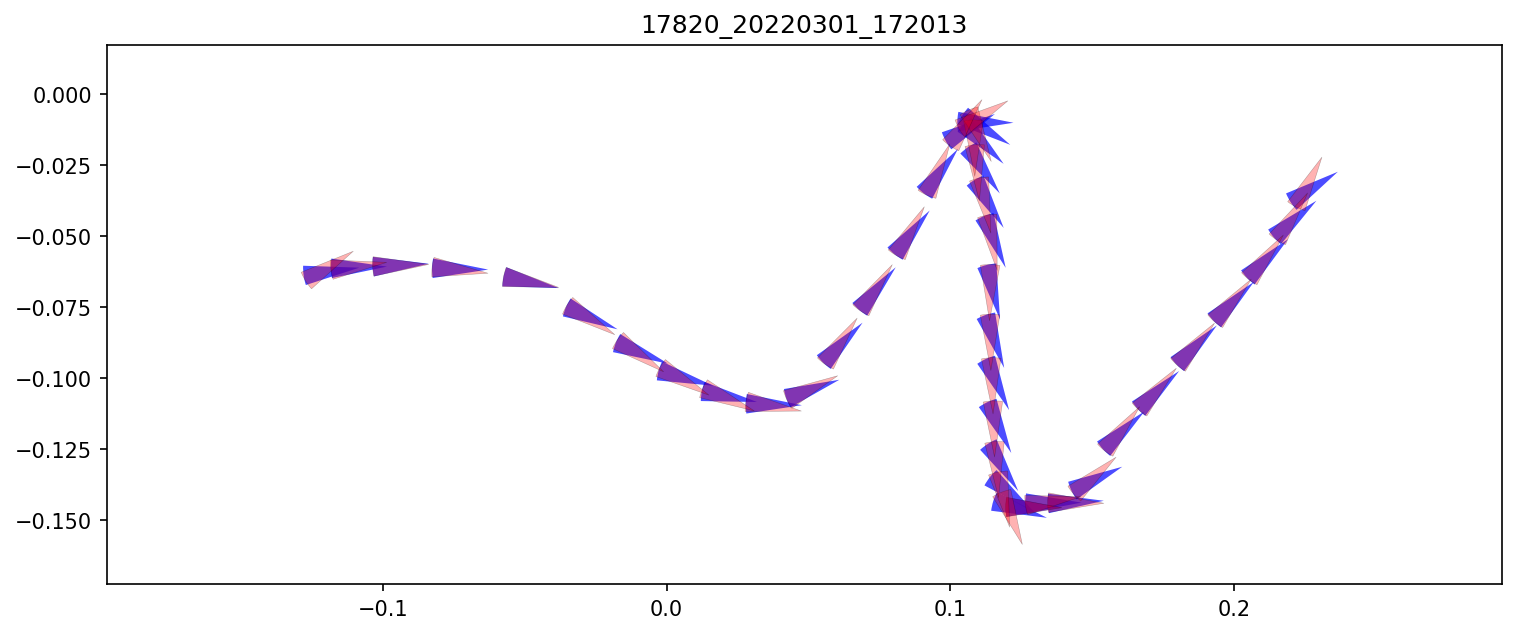

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from keras.models import load_model
from utils import plot_trajectory_with_predicted_heading

time_window  = 4
input_names  = ['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle', 'thrust', 'thrust_angle']
output_names = ['heading_angle_x', 'heading_angle_y']
n_input = len(input_names) * time_window
time_augmentation_kwargs = {
    "time_window": time_window, "input_names": input_names,
    "output_names": output_names, "direction": "backward",
}

best_estimator = load_model('../models/drosophila_body_orientation_predictor.keras', safe_mode=False)

David_fly_data    = pd.read_csv('../pipelinedata/external/david_data_augmented.csv')
test_trajec_David = David_fly_data.loc[David_fly_data["trajec_objid"] == "17820_20220301_172013"]

fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
plot_trajectory_with_predicted_heading(test_trajec_David[100:300], ax, n_input, best_estimator,
    include_id=True, nskip=4, smooth=True, **time_augmentation_kwargs)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_2_panel_B.svg', format='svg', bbox_inches='tight')
plt.show()

##### Figure 2 Panel C

In [ ]:
from sklearn.model_selection import train_test_split

# Combined dataset (training distribution)
X = traj_augment_all.iloc[:, 0:n_input]
y = traj_augment_all.iloc[:, n_input:]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Unaugmented only (to evaluate on the real inference distribution)
X_unaug = traj_augment_original.iloc[:, 0:n_input]
y_unaug = traj_augment_original.iloc[:, n_input:]
X_train_unaug, X_test_unaug, y_train_unaug, y_test_unaug = train_test_split(X_unaug, y_unaug, test_size=0.33, random_state=42)

# Wind-augmented + wrapped only
X_wind = traj_augment_wind.iloc[:, 0:n_input]
y_wind = traj_augment_wind.iloc[:, n_input:]
X_train_wind, X_test_wind, y_train_wind, y_test_wind = train_test_split(X_wind, y_wind, test_size=0.33, random_state=42)

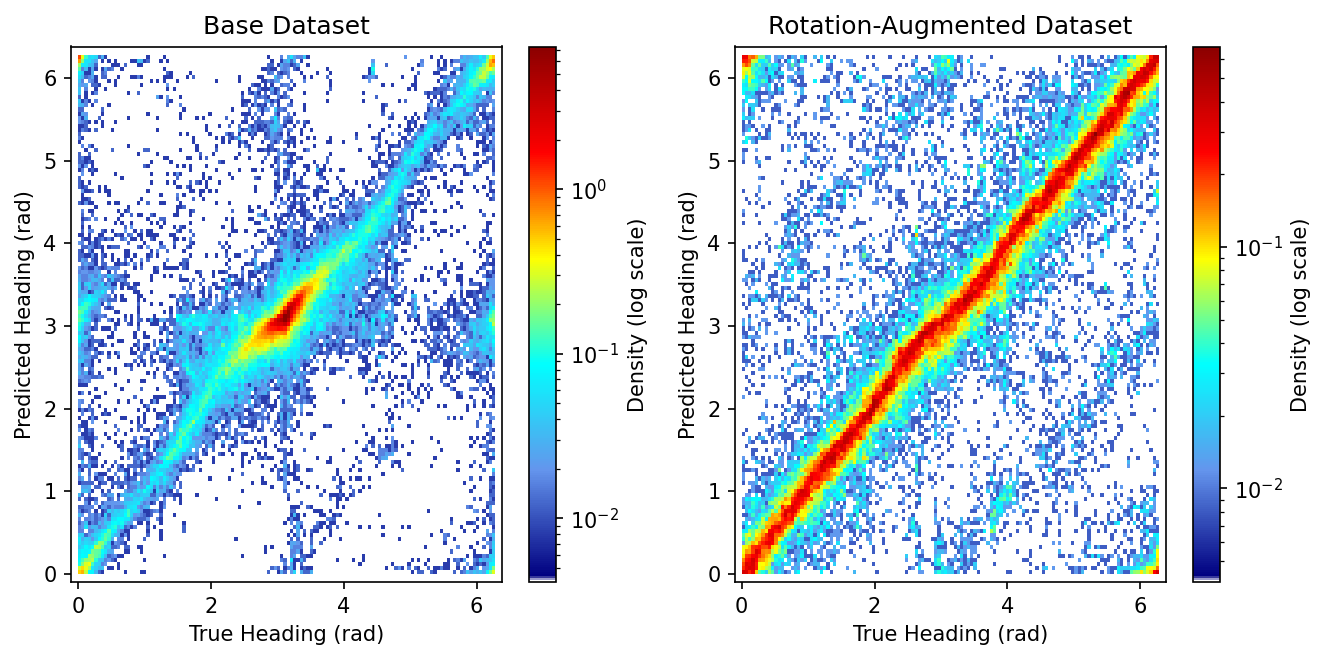

In [ ]:
import os, sys
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath('../utils'))
import pandas as pd
from keras.models import load_model
from utils import custom_density_plots, make_color_map

time_window  = 4
input_names  = ['groundspeed', 'groundspeed_angle', 'airspeed', 'airspeed_angle', 'thrust', 'thrust_angle']
output_names = ['heading_angle_x', 'heading_angle_y']
n_input = len(input_names) * time_window

best_estimator = load_model('../models/drosophila_body_orientation_predictor.keras', safe_mode=False)

traj_augment_original = pd.read_csv('../pipelinedata/07_time_delay_embedded/traj_augment_original.csv')
traj_augment_all      = pd.read_csv('../pipelinedata/08_wind_augmented/traj_augment_wind_plus_original.csv')
traj_augment_wind     = traj_augment_all.iloc[len(traj_augment_original):].reset_index(drop=True)

X_base = traj_augment_original.iloc[:, 0:n_input]
y_base = traj_augment_original.iloc[:, n_input:]

X_wind = traj_augment_wind.iloc[:, 0:n_input]
y_wind = traj_augment_wind.iloc[:, n_input:]

cmap = make_color_map(color_list=['white', 'navy', 'cornflowerblue', 'aqua', 'yellow', 'red', 'darkred'], N=256)

fig, axs = plt.subplots(1, 2, figsize=(9, 4.5), dpi=150)

custom_density_plots([axs[0], axs[1]], [X_base, X_wind], [y_base, y_wind],
                     best_estimator, cmap, titles=["Base Dataset", "Rotation-Augmented Dataset"])

fig.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/fig_2_panel_C.svg', format='svg', bbox_inches='tight')
plt.show()

### Prediction on External Data (David's Dataset)

We apply the trained estimator to an independent trajectory dataset (David's data) in which only center-of-mass motion was recorded — no body orientation measurements exist. This demonstrates the estimator's utility for recovering heading information from trajectory-only data.


#### Augment David's Data

David's dataset uses different field names and lacks the ellipse-based heading. We rename fields, add the necessary wind/airspeed columns, and run `augment_fly_trajectory` with `compute_heading_from_ellipses=False` to compute the kinematic features without overwriting the provided heading angle.


In [ ]:
from utils import augment_fly_trajectory

In [ ]:
import os
import numpy as np

from utils import augment_fly_trajectory

orco_laminar_files = [
    '../experimentaldata/external/orco_laminar1.csv',
    '../experimentaldata/external/orco_traj2.csv',
    '../experimentaldata/external/orco_traj3.csv',
]

all_dfs = []
for fpath in orco_laminar_files:
    temp = pd.read_csv(fpath)
    temp.rename(columns={
        'obj_id_unique': 'trajec_objid', 'x': 'position_x', 'y': 'position_y',
        'heading': 'heading_angle', 'xvel': 'velocity_x', 'yvel': 'velocity_y',
    }, inplace=True)
    temp = temp[["trajec_objid", "timestamp", "position_x", "position_y",
                  "velocity_x", "velocity_y", "heading_angle"]]
    temp['windspeed'] = 0.4
    temp['windspeed_angle'] = -np.pi
    temp['airvelocity_x'] = temp['velocity_x'] + 0.4
    temp['airvelocity_y'] = temp['velocity_y']
    temp['heading_angle_x'] = np.cos(temp['heading_angle'])
    temp['heading_angle_y'] = np.sin(temp['heading_angle'])
    all_dfs.append(temp)

temp_fly_data = pd.concat(all_dfs, ignore_index=True)
temp_fly_data = [group for _, group in temp_fly_data.groupby('trajec_objid')]
temp_fly_data = [t for t in temp_fly_data if len(t) > 12]
temp_fly_data = [augment_fly_trajectory(t, compute_heading_from_ellipses=False) for t in temp_fly_data]

David_fly_data = pd.concat(temp_fly_data, ignore_index=True)
os.makedirs('../pipelinedata/external', exist_ok=True)
David_fly_data.to_csv('../pipelinedata/external/david_data_augmented.csv')

#### Load Augmented External Data


In [ ]:
David_fly_data = pd.read_csv('../pipelinedata/external/david_data_augmented.csv')
body_and_trajectory_by_id = [group for _, group in David_fly_data.groupby('trajec_objid')]

#### Apply Prediction Wrapper

`plot_trajectory_with_predicted_heading` (imported from `utils`) applies the delay-embedding pipeline and runs inference, then overlays the predicted heading (blue) and true heading (red) on the trajectory plot.


#### Trajectory Plots: Predictions on External Data


In [ ]:
import random


# Loop through each trajectory and create/save figures
for trajectory in body_and_trajectory_by_id:
    trajec_objid = trajectory["trajec_objid"].iloc[0]
    fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
    plot_trajectory_with_predicted_heading(trajectory, ax, n_input, best_estimator, include_id=True, nskip=4, smooth=True, **time_augmentation_kwargs)

    os.makedirs('../figures/external_data_predicted_heading', exist_ok=True)
    svg_filename = f'../figures/external_data_predicted_heading/{trajec_objid}.svg'
    plt.savefig(svg_filename, format='svg')
    plt.close(fig)
    gc.collect()